<a href="https://colab.research.google.com/github/angelaportillo/LabPDI_IB/blob/main/P7_PDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio de PDI *"Practica 7: Segmentación óptima"*
## Hora: N5 Carrera: IB Brigada: 509
###Integrantes del equipo:
*2028256 Angela Marisa Zapata Portillo*

*2016872 Marian Roxana Martínez Serrato*

*2006071 Gabriela Mariana Rangel Carrillo*


### Docente: Ing. Noe Adiel Ponce Moreno

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [6]:
# Cargar la imagen
img = cv2.imread('/content/Te-me_0015.jpg')

# Convertir BGR -> RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Separar canales
R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]


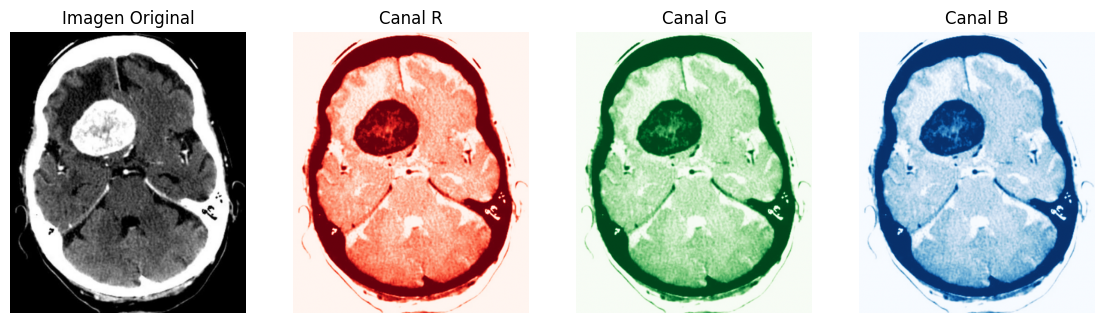

In [7]:
# MOSTRAR CANALES RGB

plt.figure(figsize=(14,4))

plt.subplot(1,4,1)
plt.imshow(img_rgb)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(R, cmap='Reds')
plt.title('Canal R')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(G, cmap='Greens')
plt.title('Canal G')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(B, cmap='Blues')
plt.title('Canal B')
plt.axis('off')

plt.show()

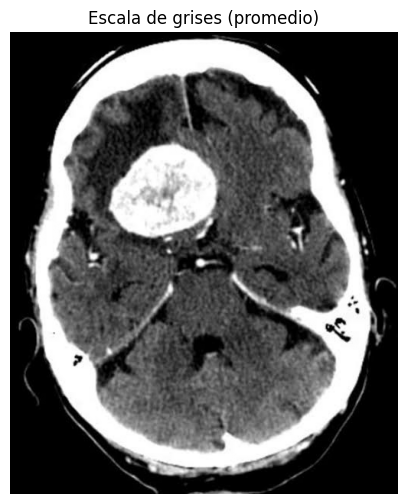

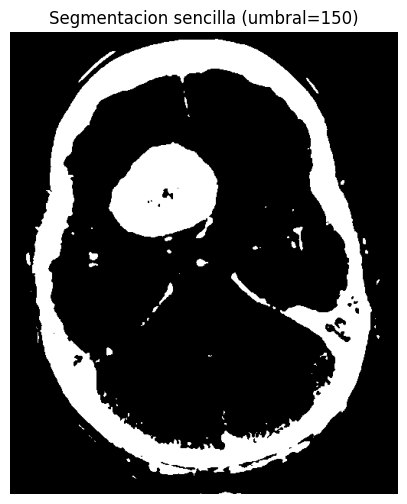

In [8]:
# SEGMENTACION SENCILLA

# Escala de grises por promedio
gray_avg = ((R.astype(np.float32) + G + B) / 3).astype(np.uint8)

plt.figure(figsize=(6,6))
plt.imshow(gray_avg, cmap='gray')
plt.title('Escala de grises (promedio)')
plt.axis('off')
plt.show()

# Umbral
umbral = 150

# Segmentacion binaria
_, seg_simple = cv2.threshold(gray_avg, umbral, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(6,6))
plt.imshow(seg_simple, cmap='gray')
plt.title(f'Segmentacion sencilla (umbral={umbral})')
plt.axis('off')
plt.show()

In [9]:
# SEGMENTACION OPTIMA

# Normalización de canales
R_norm = R.astype(np.float32) / 255
G_norm = G.astype(np.float32) / 255
B_norm = B.astype(np.float32) / 255

# Funcion objetivo
def grayscale_variance(weights):

    w_r, w_g, w_b = weights

    gray = w_r * R_norm + w_g * G_norm + w_b * B_norm

    gray_normalized = (gray - gray.min()) / (gray.max() - gray.min())

    return -np.var(gray_normalized)

# Restriccion
constraints = ({
    'type': 'eq',
    'fun': lambda w: np.sum(w) - 1
})

# Limites
bounds = [(0,1), (0,1), (0,1)]

# Pesos iniciales
initial_weights = [0.33, 0.33, 0.34]

# Optimizacion SLSQP
result = minimize(
    grayscale_variance,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

# Pesos optimos
optimal_weights = result.x

print("Pesos optimos:")
print("R =", optimal_weights[0])
print("G =", optimal_weights[1])
print("B =", optimal_weights[2])

Pesos optimos:
R = 0.33
G = 0.33
B = 0.34


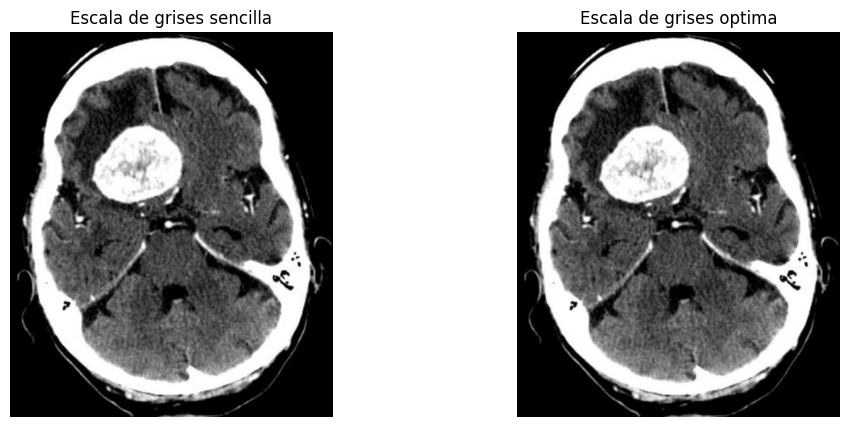

In [10]:
# IMAGEN OPTIMA EN ESCALA DE GRISES

gray_optimal = (
    optimal_weights[0] * R_norm +
    optimal_weights[1] * G_norm +
    optimal_weights[2] * B_norm
)

gray_optimal = (gray_optimal * 255).astype(np.uint8)

# Muestra de la comparacion
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(gray_avg, cmap='gray')
plt.title('Escala de grises sencilla')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gray_optimal, cmap='gray')
plt.title('Escala de grises optima')
plt.axis('off')

plt.show()

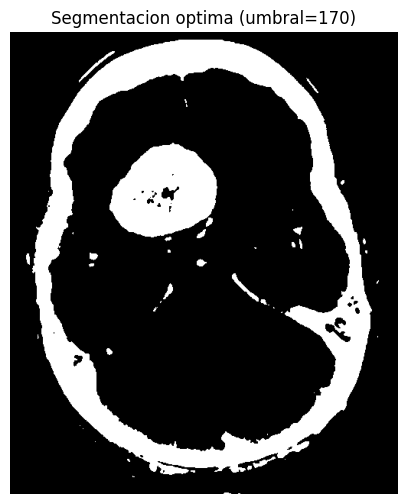

In [11]:
# SEGMENTACION OPTIMA

# Umbral para segmentacion
umbral_optimo = 170

_, seg_optimal = cv2.threshold(
    gray_optimal,
    umbral_optimo,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(6,6))
plt.imshow(seg_optimal, cmap='gray')
plt.title(f'Segmentacion optima (umbral={umbral_optimo})')
plt.axis('off')
plt.show()

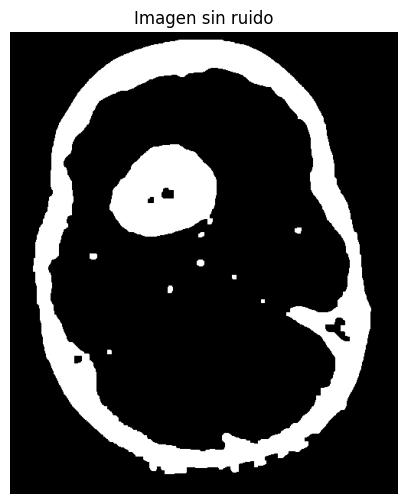

In [12]:
# ELIMINACION DE RUIDO

# Kernel morfologico
kernel = np.ones((5,5), np.uint8)

# Apertura -> elimina ruido pequeño
clean = cv2.morphologyEx(
    seg_optimal,
    cv2.MORPH_OPEN,
    kernel
)

# Cierre -> rellena huecos
clean = cv2.morphologyEx(
    clean,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(6,6))
plt.imshow(clean, cmap='gray')
plt.title('Imagen sin ruido')
plt.axis('off')
plt.show()

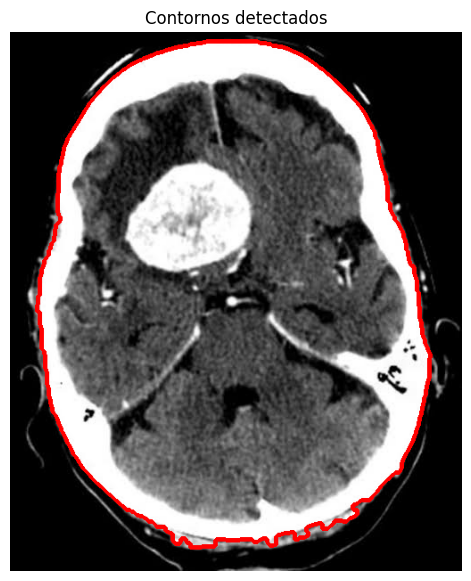

In [13]:
# DETECCION DE CONTORNOS

# Encontrar contornos
contours, _ = cv2.findContours(
    clean,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Dibujo de contornos sobre imagen original
img_contours = img_rgb.copy()

cv2.drawContours(
    img_contours,
    contours,
    -1,
    (255,0,0),
    3
)

plt.figure(figsize=(7,7))
plt.imshow(img_contours)
plt.title('Contornos detectados')
plt.axis('off')
plt.show()

In [14]:
# AREA DEL TUMOR

# Buscar el contorno mas grande
largest_contour = max(contours, key=cv2.contourArea)

# Calculo del área
tumor_area = cv2.contourArea(largest_contour)

print("Area aproximada del tumor en pixeles:")
print(tumor_area)

Area aproximada del tumor en pixeles:
196897.0


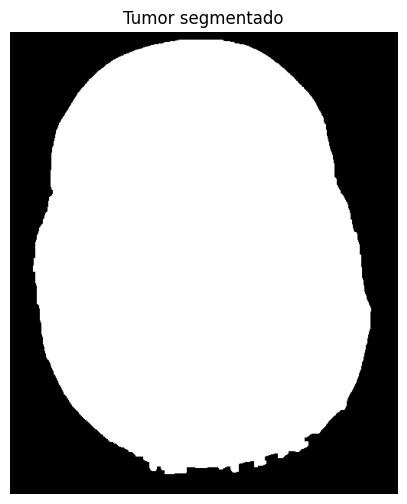

In [15]:
# MOSTRAR SOLO EL TUMOR

# Crear máscara vacía
mask = np.zeros(gray_optimal.shape, dtype=np.uint8)

# Dibujo del contorno del tumor
cv2.drawContours(mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

plt.figure(figsize=(6,6))
plt.imshow(mask, cmap='gray')
plt.title('Tumor segmentado')
plt.axis('off')
plt.show()